In [1]:
from importlib import reload
import torch
import numpy as np
import time
import os
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)
cupy_device = device.index if device.type == "cuda" else 0
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values

def f_rec(x,x_left,x_right,y_below,y_upper,center,r):
    cond= (x[:,0]>=x_left) & (x[:,0]<=x_right) & (x[:,1]>=y_below) & (x[:,1]<=y_upper)
    return cond*1

def ana_S(x,x_left,x_right,y_below,y_upper,center,r): # x is the data array; a and b are center coordinates
    return f_circle(x,x_left,x_right,y_below,y_upper,center,r)-f_rec(x,x_left,x_right,y_below,y_upper,center,r)


cuda:2


In [2]:
global Nx,Ny,kk,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center,r
Nx = 1 # the number of sub-domains 
Ny = 1
M =800 # 800 works better than 400
Qx = 29 # the number of collocation pointss per sub-domain 
Qy = 29
R_m=20
Qs=16
af="Tanh"
eps=0.05
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89] # Multiple frequencies
center_true=np.array([0.71,0.5])
x_left=0.29
x_right=0.49
y_below=0.3
y_upper=0.7
r_true=0.2
tau_x_min=0 # Support domain
tau_x_max=1
tau_y_min=0
tau_y_max=1

b_x_min=-0.5 # On boundary Gamma
b_x_max=1.5
b_y_min=-0.5
b_y_max=1.5
number_gene=50 # Gauss points for data generation
number_appr=100 # Number of Gauss points for approximation
num_batches=1
model1 = net_2d.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
b_n=10# Samples per boundary side
points_b=mea_2d.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) # Collect data on boundary Gamma
cupy_device = device.index if device.type == "cuda" else 0
batch_number_rec_mea,mea=2,1
S_int_true1, F_mea_b1, F_mea_db_x11, F_mea_db_x21 = generate_data.boundary_data_rec(kk, number_gene,points_b, f_rec, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true2, F_mea_b2, F_mea_db_x12, F_mea_db_x22 = generate_data.boundary_data_circle(kk, number_gene,points_b, f_circle, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
F_mea_b = -F_mea_b1 + F_mea_b2
F_mea_db_x1 = -F_mea_db_x11 + F_mea_db_x12
F_mea_db_x2 = -F_mea_db_x21 + F_mea_db_x22
F=inverse_solver.F(F_mea_b,F_mea_db_x1,F_mea_db_x2)
num_nn=1
choose="rec"


In [3]:
num_batches_gauss=100 # Number of Gauss-point batches
batch_number_mea=1 # Number of measurement batches
grad_temp=0
S_basis,b_matrix,db_x1_matrix,db_x2_matrix,grads_y1,grads_y2=matrix_assemble.residual_vector(model1,points_b,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center_true,r_true,M,af,choose,mea,kk,number_appr,num_batches_gauss,batch_number_mea,grad_temp,device,cupy_device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


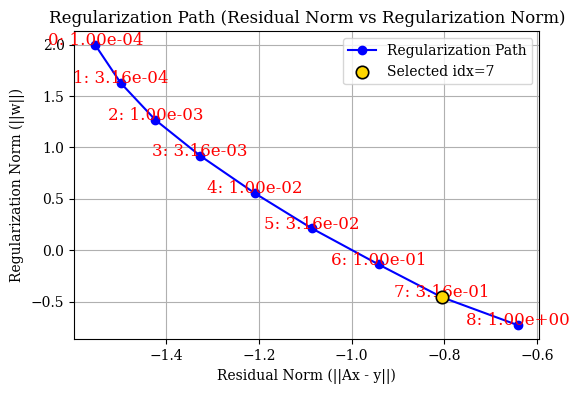

In [4]:
all_mat=inverse_solver.A(b_matrix,db_x1_matrix,db_x2_matrix)
lamb_regu=np.logspace(-4,0,9,endpoint=True) # 10-5, 10-4.5,..., 10+0.5, 10+1
res,reg_norm,w_store=inverse_solver.L_curve(all_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) # Solve first

L-curve corner index: 7
Curvature-centered lambda window:
  idx=6, lambda=1.000000e-01, curvature=5.823638e-02
  idx=7, lambda=3.162278e-01, curvature=1.429261e-01 <== center
  idx=8, lambda=1.000000e+00, curvature=0.000000e+00
candidate idx: [6 7 8]
candidate lambda: [0.1        0.31622777 1.        ]


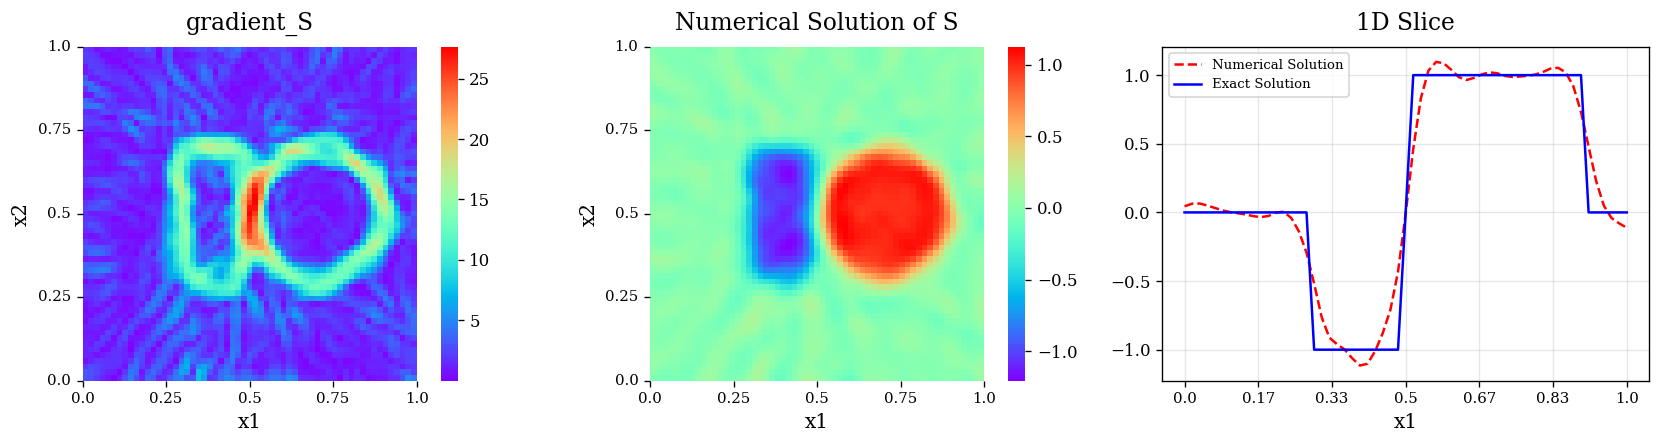

S_l_inf= 1.6479721212692686 S_L_2= 0.131185541798003 S_l_2= 0.29191762862653053
candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.6479721212692686, S_l_2=0.29191762862653053


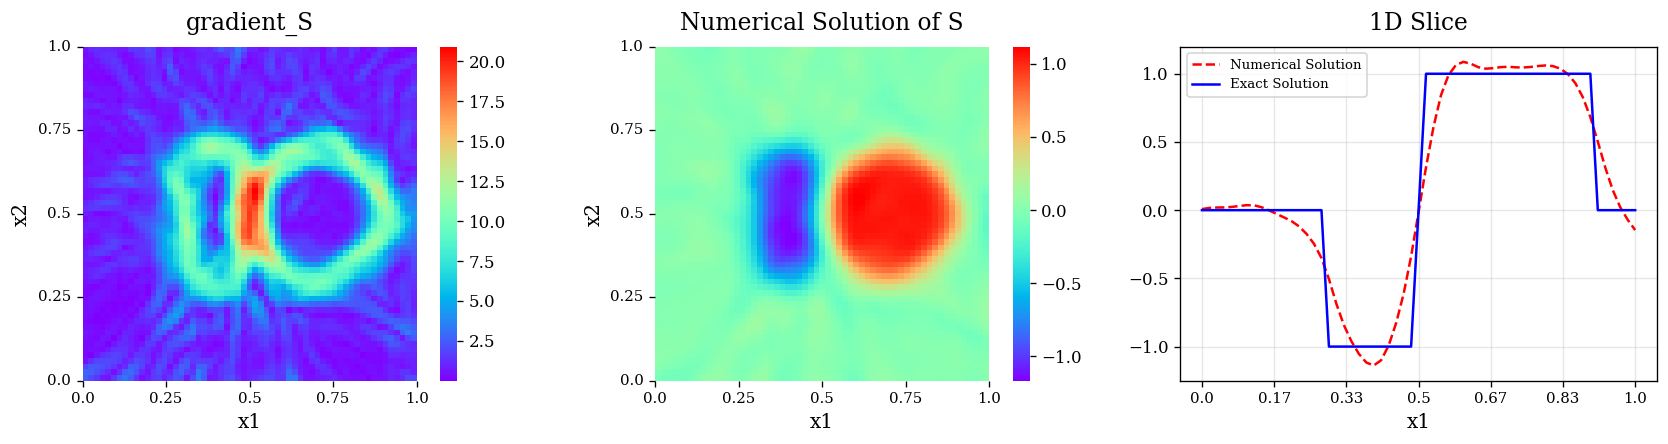

S_l_inf= 1.7278644037307458 S_L_2= 0.1511697918314804 S_l_2= 0.3363871242713714
candidate idx=7, lamb=0.1, S_l_inf=1.7278644037307458, S_l_2=0.3363871242713714


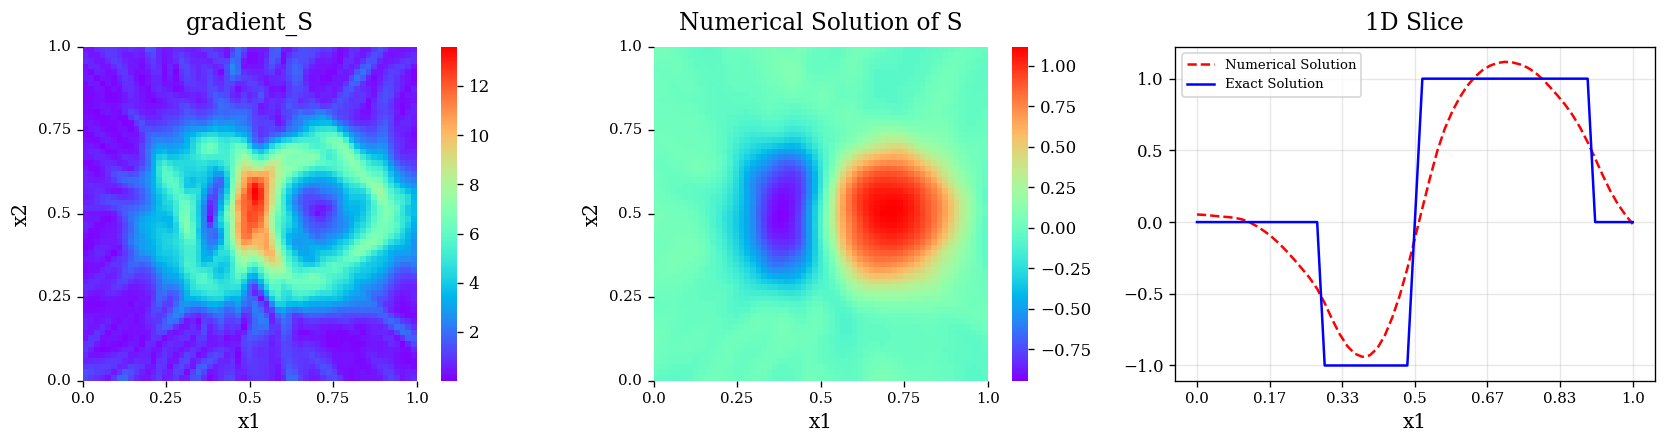

S_l_inf= 2.126439309190505 S_L_2= 0.1962944647282422 S_l_2= 0.4367997713057041
candidate idx=8, lamb=1.0, S_l_inf=2.126439309190505, S_l_2=0.4367997713057041
picked idx: 6
lamb: 0.010000000000000002


In [5]:
reload(inverse_solver)
window_idx, window_lambda, window_w, curvature = inverse_solver.lambda_window_by_curvature(
    lamb_regu, res, reg_norm, radius=1, w_store=w_store
)
print('candidate idx:', window_idx)
print('candidate lambda:', window_lambda)
window_results = []
for local_i, cand_idx in enumerate(window_idx):
    cand_lamb = window_lambda[local_i]**2
    cand_w = window_w[:, local_i]
    result_tuple = error_general_2d.test(model1,[],[],M,Qx,Qy,cand_w,af,[],[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)
    window_results.append({
        'idx': int(cand_idx),
        'lambda': cand_lamb,
        'w': cand_w,
        'result': result_tuple,
    })
    print(
        f"candidate idx={int(cand_idx)}, lamb={cand_lamb}, "
        f"S_l_inf={result_tuple[2]}, S_l_2={result_tuple[3]}"
    )
pick = 0
picked = window_results[pick]
idx = picked['idx']
lamb = picked['lambda']
picked_w = picked['w']
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=picked['result']
print('picked idx:', idx)
print('lamb:', lamb)


In [6]:
M=1600
model_1600 = net_2d.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
num_batches_gauss=100 # Number of Gauss-point batches
batch_number_mea=1 # Number of measurement batches
grad_temp=0
S_basis,b_matrix,db_x1_matrix,db_x2_matrix,grads_y1,grads_y2=matrix_assemble.residual_vector(model_1600,points_b,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center_true,r_true,M,af,choose,mea,kk,number_appr,num_batches_gauss,batch_number_mea,grad_temp,device,cupy_device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


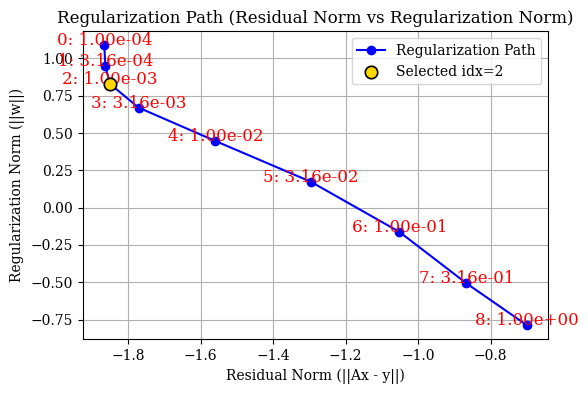

In [7]:
all_mat=inverse_solver.A(b_matrix,db_x1_matrix,db_x2_matrix)
lamb_regu=np.logspace(-4,0,9,endpoint=True) # 10-5, 10-4.5,..., 10+0.5, 10+1
res,reg_norm,w_store=inverse_solver.L_curve(all_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) # Solve first

L-curve corner index: 2
Curvature-centered lambda window:
  idx=1, lambda=3.162278e-04, curvature=6.319517e-01
  idx=2, lambda=1.000000e-03, curvature=1.131088e+00 <== center
  idx=3, lambda=3.162278e-03, curvature=3.252042e-01
candidate idx: [1 2 3]
candidate lambda: [0.00031623 0.001      0.00316228]


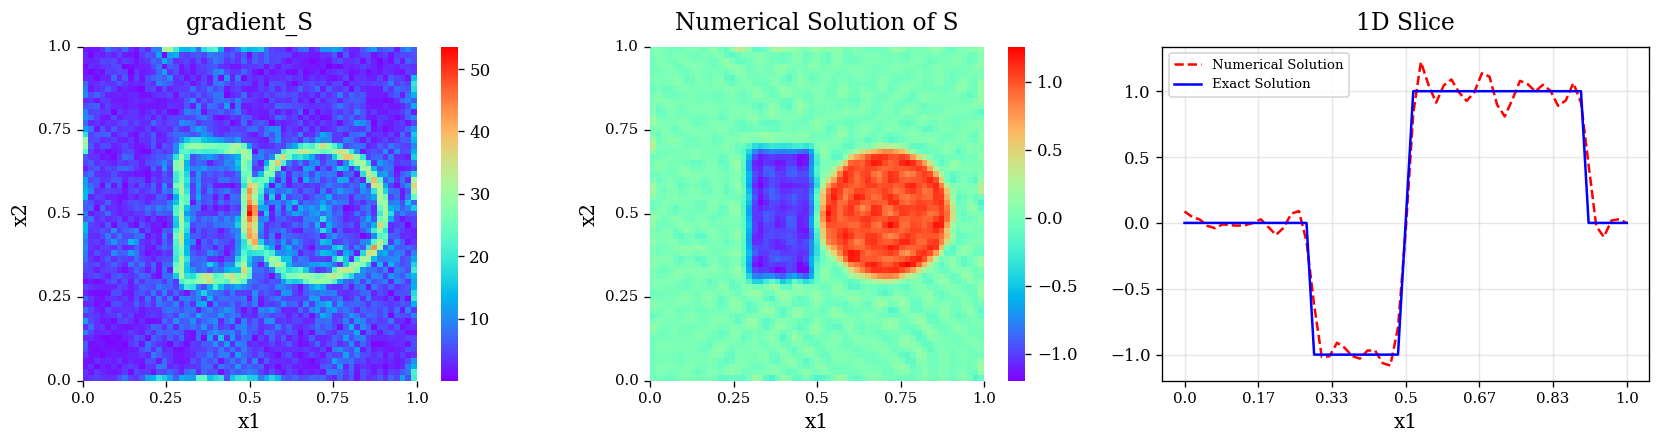

S_l_inf= 1.3063763528172385 S_L_2= 0.1016702378111105 S_l_2= 0.22623937300510194
candidate idx=1, lamb=1.0000000000000001e-07, S_l_inf=1.3063763528172385, S_l_2=0.22623937300510194


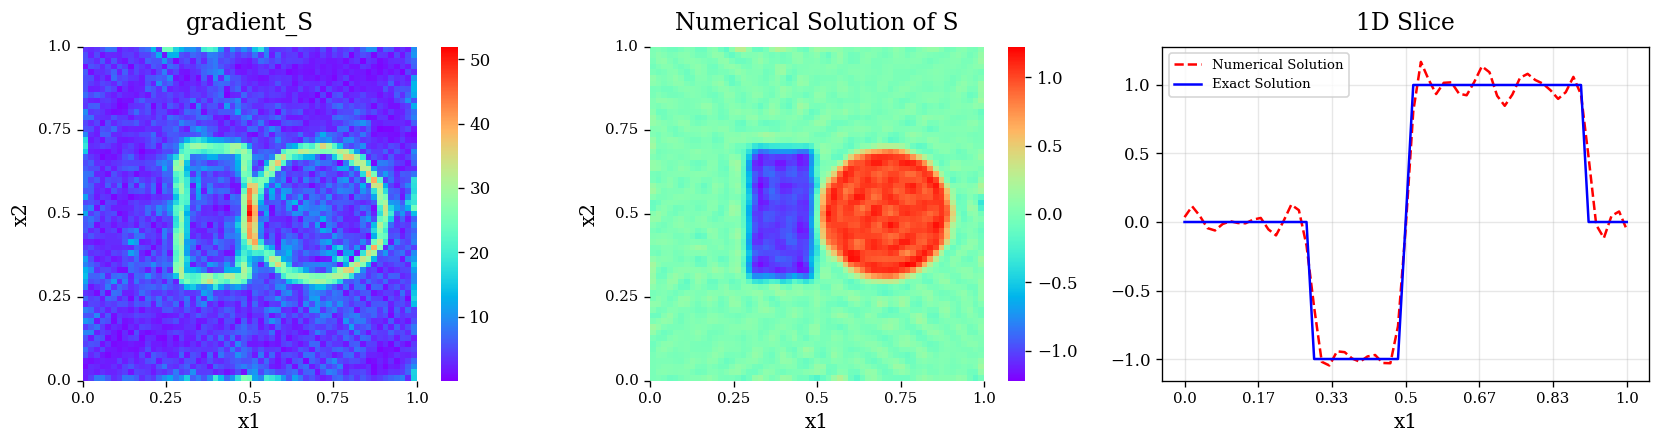

S_l_inf= 1.3808519508579498 S_L_2= 0.09858202131822773 S_l_2= 0.21936738983583015
candidate idx=2, lamb=1e-06, S_l_inf=1.3808519508579498, S_l_2=0.21936738983583015


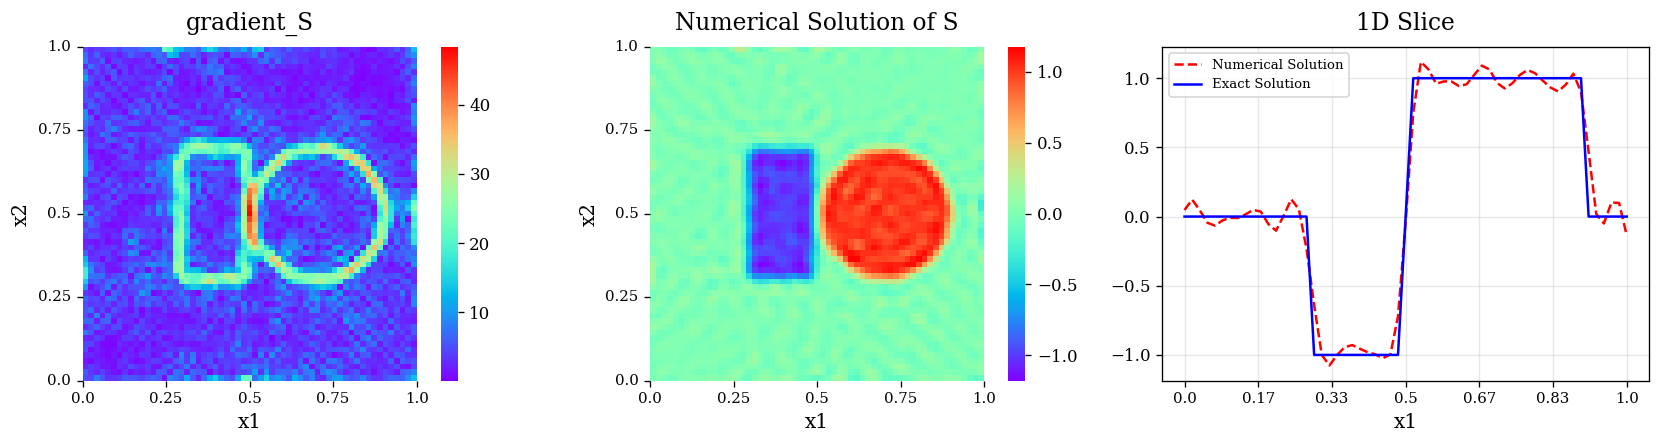

S_l_inf= 1.4033691294973683 S_L_2= 0.0980298509207262 S_l_2= 0.2181386852787029
candidate idx=3, lamb=1e-05, S_l_inf=1.4033691294973683, S_l_2=0.2181386852787029
picked idx: 1
lamb: 1.0000000000000001e-07


In [8]:
reload(inverse_solver)
window_idx, window_lambda, window_w, curvature = inverse_solver.lambda_window_by_curvature(
    lamb_regu, res, reg_norm, radius=1, w_store=w_store
)
print('candidate idx:', window_idx)
print('candidate lambda:', window_lambda)
window_results = []
for local_i, cand_idx in enumerate(window_idx):
    cand_lamb = window_lambda[local_i]**2
    cand_w = window_w[:, local_i]
    result_tuple = error_general_2d.test(model_1600,[],[],M,Qx,Qy,cand_w,af,[],[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)
    window_results.append({
        'idx': int(cand_idx),
        'lambda': cand_lamb,
        'w': cand_w,
        'result': result_tuple,
    })
    print(
        f"candidate idx={int(cand_idx)}, lamb={cand_lamb}, "
        f"S_l_inf={result_tuple[2]}, S_l_2={result_tuple[3]}"
    )
pick = 0
picked = window_results[pick]
idx = picked['idx']
lamb = picked['lambda']
picked_w = picked['w']
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=picked['result']
print('picked idx:', idx)
print('lamb:', lamb)


In [9]:
M=3200
model_3200 = net_2d.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
num_batches_gauss=100 # Number of Gauss-point batches
batch_number_mea=1 # Number of measurement batches
grad_temp=0
S_basis,b_matrix,db_x1_matrix,db_x2_matrix,grads_y1,grads_y2=matrix_assemble.residual_vector(model_3200,points_b,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center_true,r_true,M,af,choose,mea,kk,number_appr,num_batches_gauss,batch_number_mea,grad_temp,device,cupy_device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


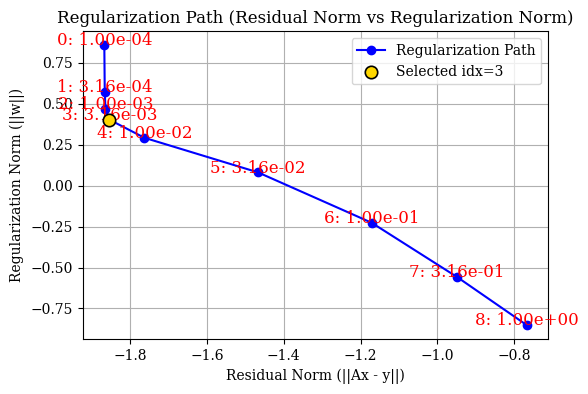

In [10]:
all_mat=inverse_solver.A(b_matrix,db_x1_matrix,db_x2_matrix)
lamb_regu=np.logspace(-4,0,9,endpoint=True) # 10-5, 10-4.5,..., 10+0.5, 10+1
res,reg_norm,w_store=inverse_solver.L_curve(all_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) # Solve first

L-curve corner index: 3
Curvature-centered lambda window:
  idx=2, lambda=1.000000e-03, curvature=1.734007e+00
  idx=3, lambda=3.162278e-03, curvature=2.586692e+00 <== center
  idx=4, lambda=1.000000e-02, curvature=8.906191e-02
candidate idx: [2 3 4]
candidate lambda: [0.001      0.00316228 0.01      ]


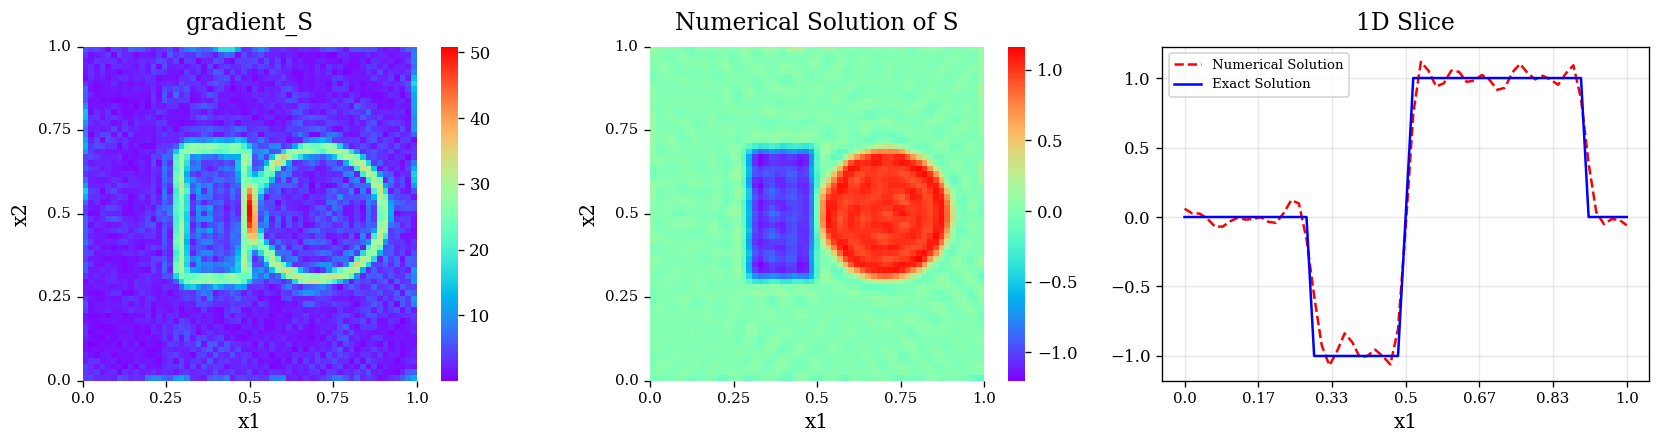

S_l_inf= 1.2906638426142556 S_L_2= 0.08900107578513959 S_l_2= 0.1980476097618524
candidate idx=2, lamb=1e-06, S_l_inf=1.2906638426142556, S_l_2=0.1980476097618524


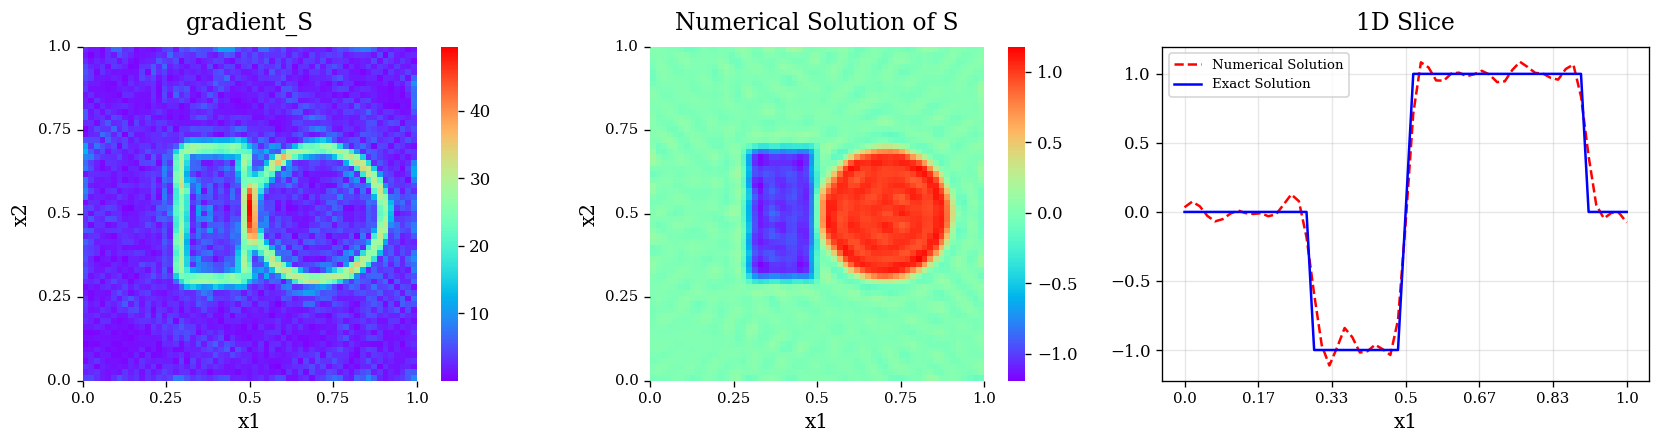

S_l_inf= 1.3167004418499018 S_L_2= 0.08960239031936787 S_l_2= 0.1993856711860364
candidate idx=3, lamb=1e-05, S_l_inf=1.3167004418499018, S_l_2=0.1993856711860364


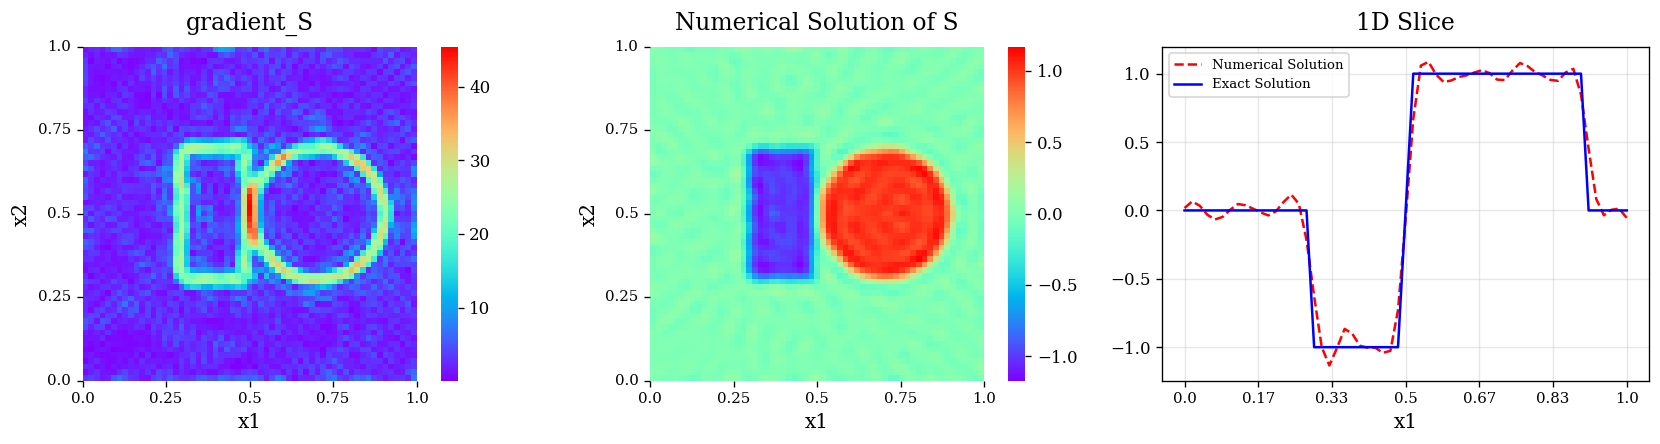

S_l_inf= 1.3614322476170075 S_L_2= 0.0927622243283356 S_l_2= 0.20641701959615033
candidate idx=4, lamb=0.0001, S_l_inf=1.3614322476170075, S_l_2=0.20641701959615033
picked idx: 2
lamb: 1e-06


In [11]:
reload(inverse_solver)
window_idx, window_lambda, window_w, curvature = inverse_solver.lambda_window_by_curvature(
    lamb_regu, res, reg_norm, radius=1, w_store=w_store
)
print('candidate idx:', window_idx)
print('candidate lambda:', window_lambda)
window_results = []
for local_i, cand_idx in enumerate(window_idx):
    cand_lamb = window_lambda[local_i]**2
    cand_w = window_w[:, local_i]
    result_tuple = error_general_2d.test(model_3200,[],[],M,Qx,Qy,cand_w,af,[],[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)
    window_results.append({
        'idx': int(cand_idx),
        'lambda': cand_lamb,
        'w': cand_w,
        'result': result_tuple,
    })
    print(
        f"candidate idx={int(cand_idx)}, lamb={cand_lamb}, "
        f"S_l_inf={result_tuple[2]}, S_l_2={result_tuple[3]}"
    )
pick = 0
picked = window_results[pick]
idx = picked['idx']
lamb = picked['lambda']
picked_w = picked['w']
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=picked['result']
print('picked idx:', idx)
print('lamb:', lamb)


In [12]:
M=6400
model_6400 = net_2d.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
num_batches_gauss=100 # Number of Gauss-point batches
batch_number_mea=1 # Number of measurement batches
grad_temp=0
S_basis,b_matrix,db_x1_matrix,db_x2_matrix,grads_y1,grads_y2=matrix_assemble.residual_vector(model_6400,points_b,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center_true,r_true,M,af,choose,mea,kk,number_appr,num_batches_gauss,batch_number_mea,grad_temp,device,cupy_device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


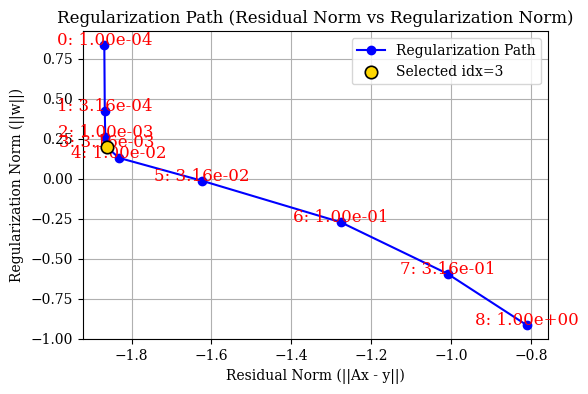

In [13]:
all_mat=inverse_solver.A(b_matrix,db_x1_matrix,db_x2_matrix)
lamb_regu=np.logspace(-4,0,9,endpoint=True) # 10-5, 10-4.5,..., 10+0.5, 10+1
res,reg_norm,w_store=inverse_solver.L_curve(all_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) # Solve first

L-curve corner index: 3
Curvature-centered lambda window:
  idx=2, lambda=1.000000e-03, curvature=3.460832e-01
  idx=3, lambda=3.162278e-03, curvature=5.493174e+00 <== center
  idx=4, lambda=1.000000e-02, curvature=6.125705e-01
candidate idx: [2 3 4]
candidate lambda: [0.001      0.00316228 0.01      ]


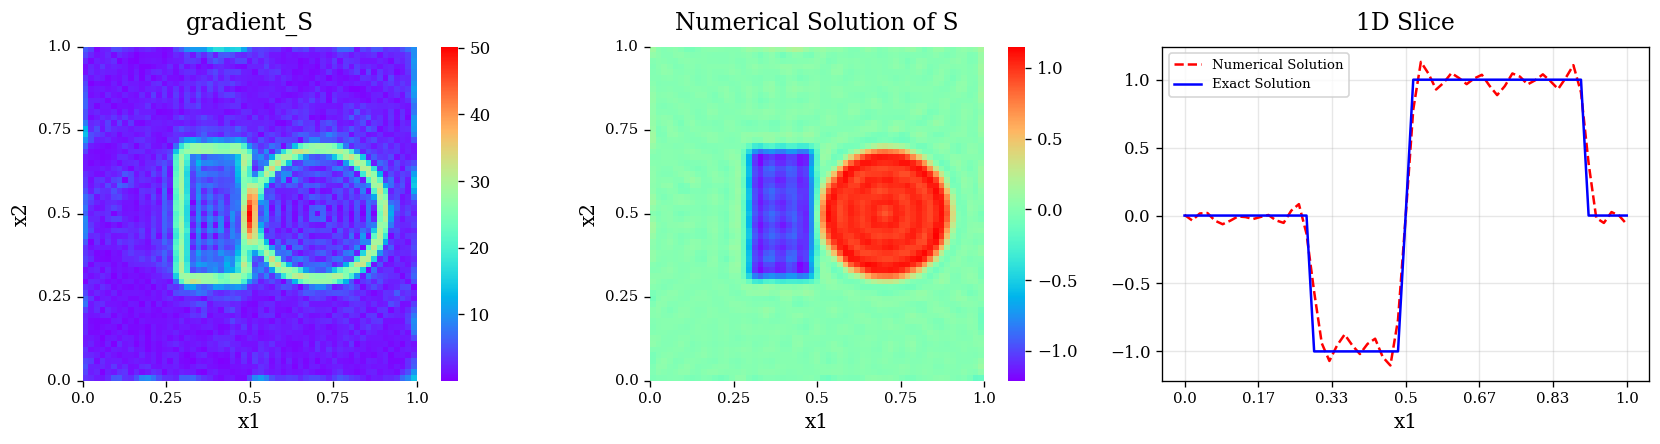

S_l_inf= 1.2748224205591472 S_L_2= 0.08774675115910378 S_l_2= 0.19525645255548862
candidate idx=2, lamb=1e-06, S_l_inf=1.2748224205591472, S_l_2=0.19525645255548862


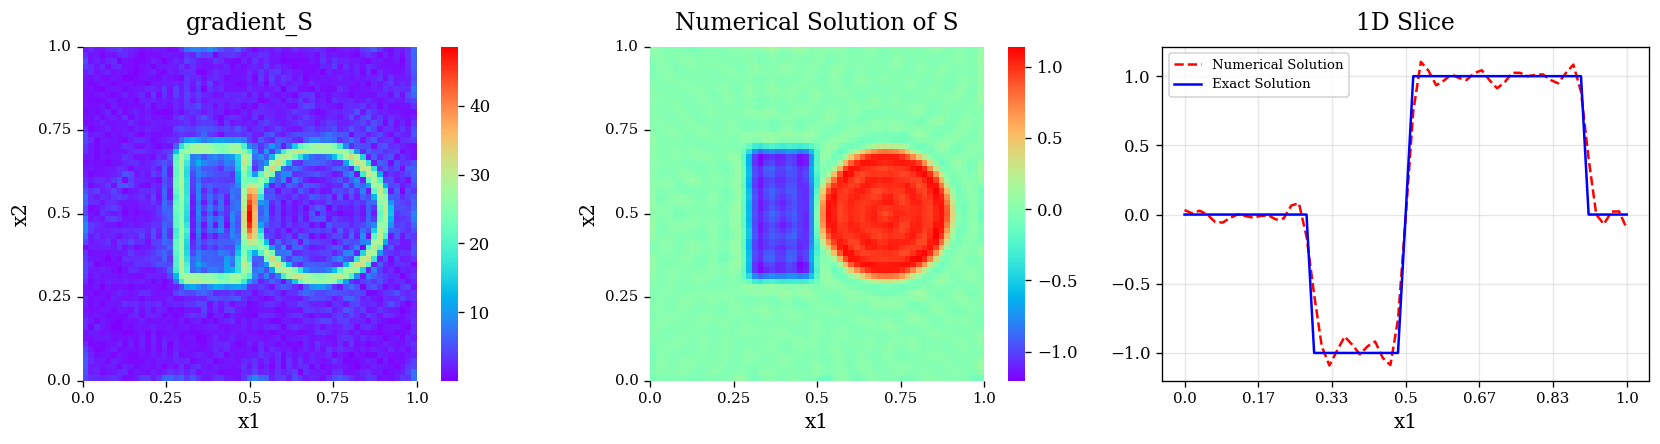

S_l_inf= 1.3110311753893982 S_L_2= 0.08744665629483901 S_l_2= 0.19458867331748342
candidate idx=3, lamb=1e-05, S_l_inf=1.3110311753893982, S_l_2=0.19458867331748342


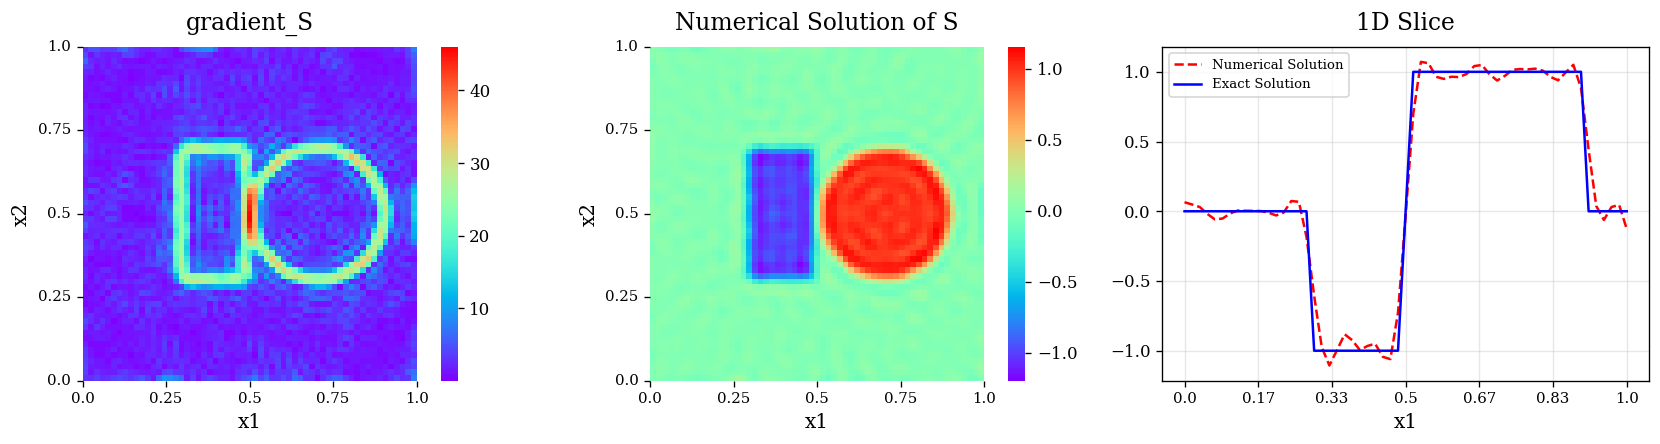

S_l_inf= 1.3472472233054187 S_L_2= 0.08975255362804202 S_l_2= 0.19971981865666522
candidate idx=4, lamb=0.0001, S_l_inf=1.3472472233054187, S_l_2=0.19971981865666522
picked idx: 2
lamb: 1e-06


In [14]:
reload(inverse_solver)
window_idx, window_lambda, window_w, curvature = inverse_solver.lambda_window_by_curvature(
    lamb_regu, res, reg_norm, radius=1, w_store=w_store
)
print('candidate idx:', window_idx)
print('candidate lambda:', window_lambda)
window_results = []
for local_i, cand_idx in enumerate(window_idx):
    cand_lamb = window_lambda[local_i]**2
    cand_w = window_w[:, local_i]
    result_tuple = error_general_2d.test(model_6400,[],[],M,Qx,Qy,cand_w,af,[],[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)
    window_results.append({
        'idx': int(cand_idx),
        'lambda': cand_lamb,
        'w': cand_w,
        'result': result_tuple,
    })
    print(
        f"candidate idx={int(cand_idx)}, lamb={cand_lamb}, "
        f"S_l_inf={result_tuple[2]}, S_l_2={result_tuple[3]}"
    )
pick = 0
picked = window_results[pick]
idx = picked['idx']
lamb = picked['lambda']
picked_w = picked['w']
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=picked['result']
print('picked idx:', idx)
print('lamb:', lamb)
